<a href="https://colab.research.google.com/github/HarshithaBoppudi/part-3-nlp-sequence-modeling/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Number of records: 1500
Number of columns: 6

Target labels: ['neutral' 'positive' 'negative']

Class distribution:
 sentiment_label
neutral     524
negative    497
positive    479
Name: count, dtype: int64

Sample records:
                                       customer_message sentiment_label
1116  I am checking if there is any scheduled mainte...         neutral
1368  The app experience is smooth and reliable. I a...        positive
422   Can you confirm whether my ticket has been ass...         neutral
413   I have raised multiple tickets but nobody has ...        negative
451   Billing is incorrect and I was charged twice t...        negative

Average text length (words): 12.72


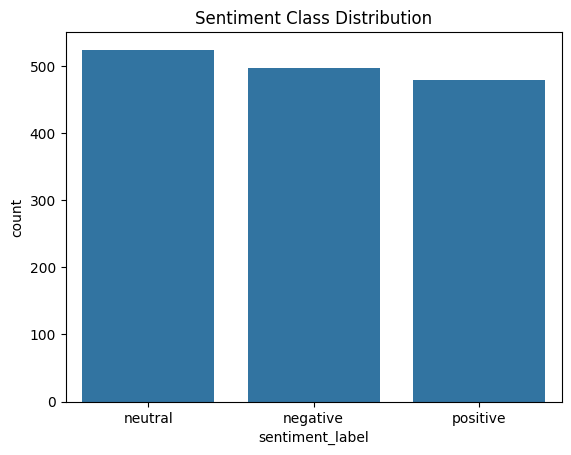

In [6]:
# =========================
# Task 1: Dataset Understanding
# =========================
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("customer_support_text_classification.csv")

print("Number of records:", len(df))
print("Number of columns:", df.shape[1])

print("\nTarget labels:", df['sentiment_label'].unique())
print("\nClass distribution:\n", df['sentiment_label'].value_counts())

print("\nSample records:")
print(df[['customer_message','sentiment_label']].sample(5, random_state=42))

print("\nAverage text length (words):", round(df['word_count'].mean(),2))

sns.countplot(x='sentiment_label', data=df,
              order=df['sentiment_label'].value_counts().index)
plt.title("Sentiment Class Distribution")
plt.show()


In [7]:
# =========================
# Task 2: Text Preprocessing
# =========================
import re
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()                          # lowercasing
    text = re.sub(r'[^a-z\s]', '', text)         # remove special chars/numbers
    tokens = text.split()
    tokens = [w for w in tokens if w not in stop_words]  # remove stopwords
    return " ".join(tokens)

df['clean_message'] = df['customer_message'].apply(clean_text)

print(df[['customer_message','clean_message']].head())


                                    customer_message  \
0  I need information about the payment process. ...   
1      I need information about the payment process.   
2  The refund process was fast and convenient. I ...   
3  My refund is still pending and this experience...   
4   Please tell me how to update my account details.   

                                       clean_message  
0  need information payment process ticket number...  
1                   need information payment process  
2  refund process fast convenient appreciate quic...  
3  refund still pending experience frustrating ti...  
4                 please tell update account details  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# =========================
# Task 3: Text Vectorization
# =========================
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000)
X_tfidf = tfidf.fit_transform(df['clean_message'])

y = df['sentiment_label']

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (1500, 146)


In [9]:
# =========================
# Task 4: Baseline Model
# =========================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

baseline_model = LogisticRegression(max_iter=1000)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline Model Evaluation:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Baseline Model Evaluation:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00        99
     neutral       1.00      1.00      1.00       105
    positive       1.00      1.00      1.00        96

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300

Confusion Matrix:
 [[ 99   0   0]
 [  0 105   0]
 [  0   0  96]]


In [10]:
# =========================
# Task 5: Sequence Model (LSTM)
# =========================
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Tokenize
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_message'])
X_seq = tokenizer.texts_to_sequences(df['clean_message'])
X_pad = pad_sequences(X_seq, maxlen=50, padding='post')

# Encode labels
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
y_enc = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X_pad, y_enc, test_size=0.2, random_state=42, stratify=y_enc)

# Build LSTM model
model = Sequential([
    Embedding(input_dim=5000, output_dim=64, input_length=50),
    LSTM(64),
    Dense(32, activation='relu'),
    Dense(3, activation='softmax')  # 3 sentiment classes
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=5,
                    validation_data=(X_test, y_test), batch_size=32)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print(f"LSTM Test Accuracy: {acc:.4f}, Loss: {loss:.4f}")


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


38/38 ━━━━━━━━━━━━━━━━━━━━ 14s 136ms/step - accuracy: 0.3292 - loss: 1.0994 - val_accuracy: 0.3500 - val_loss: 1.0979
Epoch 2/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 105ms/step - accuracy: 0.3483 - loss: 1.0983 - val_accuracy: 0.3500 - val_loss: 1.1004
Epoch 3/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3492 - loss: 1.0993 - val_accuracy: 0.3500 - val_loss: 1.0982
Epoch 4/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.3467 - loss: 1.0989 - val_accuracy: 0.3300 - val_loss: 1.0991
Epoch 5/5
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.3292 - loss: 1.0993 - val_accuracy: 0.3500 - val_loss: 1.0980
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.3500 - loss: 1.0980
LSTM Test Accuracy: 0.3500, Loss: 1.0980


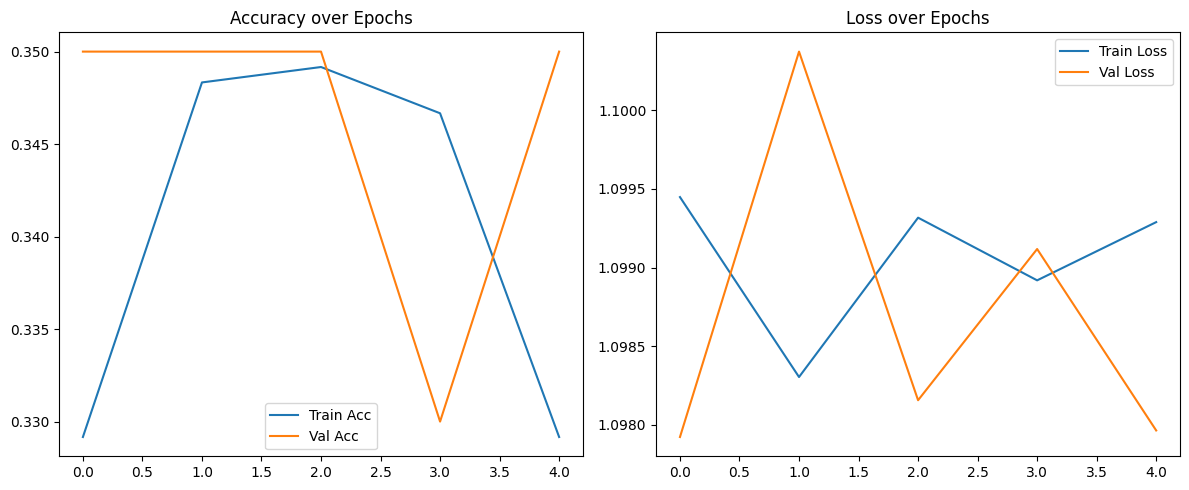

In [12]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy over Epochs")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss over Epochs")
plt.legend()

plt.tight_layout()
plt.show()


In [16]:
import numpy as np

# Pick 10 random samples from test set
sample_idx = np.random.choice(len(X_test), 10, replace=False)

# Get LSTM predictions
y_pred_lstm_probs = model.predict(X_test)
y_pred_lstm_classes = np.argmax(y_pred_lstm_probs, axis=1)

with open("sample_predictions.txt", "w") as f:
    for i in sample_idx:
        # Reconstruct cleaned message from X_test since original df index is not directly available
        msg = tokenizer.sequences_to_texts([X_test[i]])[0]
        true_label = le.inverse_transform([y_test[i]])[0]
        pred_label = le.inverse_transform([y_pred_lstm_classes[i]])[0]
        f.write(f"Message: {msg}\nTrue Label: {true_label}\nPredicted Label: {pred_label}\n\n")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step
